#Trabajo Práctico 2 - Críticas Cinematográficas

#Grupo 2 - G2 - Integrantes:

- Calderan, Facundo Andres
- Merlinsky Camins, Mariano Gabriel
- Castellano Bogdan, Benjamin
- Pons Echeverria, Tomas

# XGBoost


In [1]:
import pandas as pd

# Descargamos los archivos
!gdown 1MV2mivzC_7gLCqRndSnWizXRGhJBgQ6L
!gdown 1GpCc2ggdH9X4nrfbO80ubK4GF5NGtrzk

# Descargamos intelex para acelerar a ScikitLearn
!pip install scikit-learn-intelex -q --progress-bar off
# Descargamos langid
!pip install langid

Downloading...
From: https://drive.google.com/uc?id=1MV2mivzC_7gLCqRndSnWizXRGhJBgQ6L
To: /content/test.csv
100% 11.1M/11.1M [00:00<00:00, 52.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1GpCc2ggdH9X4nrfbO80ubK4GF5NGtrzk
To: /content/train.csv
100% 72.2M/72.2M [00:00<00:00, 100MB/s] 
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 26.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langid: filename=langid-1.1.6-py3-none-any.whl size=1941171 sha256=435c7123ccffb748f7c9a0eeea215241e8d303cbeb10c376482a252b15f1aba5
  Stored in directory: /root/.cache/pip/wheels/3c/bc/9d/266e27289b9019680d65d9b608c37bff1eff565b001c977ec5
Successfully built langid


In [2]:
# Cargamos los archivos en dataframes
data_train = pd.read_csv('train.csv')
data_test = pd.read_csv('test.csv')

print(data_train.info())
data_train

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           50000 non-null  int64 
 1   review_es    50000 non-null  object
 2   sentimiento  50000 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB
None


,ID,review_es,sentimiento
0,0,Uno de los otros críticos ha mencionado que de...,positivo
1,1,Una pequeña pequeña producción.La técnica de f...,positivo
2,2,Pensé que esta era una manera maravillosa de p...,positivo
3,3,"Básicamente, hay una familia donde un niño peq...",negativo
4,4,"El ""amor en el tiempo"" de Petter Mattei es una...",positivo
...,...,...,...
49995,49995,Pensé que esta película hizo un buen trabajo a...,positivo
49996,49996,"Mala parcela, mal diálogo, mala actuación, dir...",negativo
49997,49997,Soy católica enseñada en escuelas primarias pa...,negativo
49998,49998,Voy a tener que estar en desacuerdo con el com...,negativo


Sacamos criíticas que no estén en español

In [3]:
import langid

def detectar_idioma(texto):
    lang, prob = langid.classify(texto)
    return lang

data_train['idioma'] = data_train['review_es'].apply(detectar_idioma)

data_train = data_train[data_train['idioma'] == 'es']
data_train = data_train.drop('idioma', axis=1)

In [4]:
X = data_train['review_es']
y = data_train['sentimiento']
x_test = data_test['review_es']

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sentence_transformers import SentenceTransformer
from sklearnex import patch_sklearn
import torch

# Utilizamos sentence embedding para capturar la semántica de las oraciones
model = SentenceTransformer("hiiamsid/sentence_similarity_spanish_es", device='cuda', model_kwargs={"dtype": torch.bfloat16})

X = X.reset_index(drop=True)

X_train_emb = model.encode(X,batch_size=32 ,show_progress_bar=True)
X_test_emb = model.encode(x_test,batch_size=32, show_progress_bar=True)

scaler = StandardScaler()
X_train_emb = scaler.fit_transform(X_train_emb)
X_test_emb = scaler.transform(X_test_emb)



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1506 [00:00<?, ?it/s]

Batches:   0%|          | 0/269 [00:00<?, ?it/s]

In [ ]:
import numpy as np
np.save("train_emb.npy", X_train_emb)
np.save("test_emb.npy", X_test_emb)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Los embeddings hay que correrlos con GPU
# Importante: descargarse los emb para cuando se reinicie el entorno y subirlos a los archivos del colab

X_train_a = np.load("train_emb.npy")
X_test_a = np.load("test_emb.npy")

print(X_train_a)
print(X_test_a.shape)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_val, y_train, y_val = train_test_split(X_train_a, y_encoded,
                                                            test_size = 0.2,
                                                            random_state = 42,
                                                            stratify = y
)

[[-0.9909666   0.73021156 -1.165175   ... -0.34301904  0.35789615
  -0.12629664]
 [-0.06768981  1.1367652   0.53578186 ... -1.790469   -0.47189096
  -1.1285605 ]
 [-0.95531887  0.5675901  -0.08388209 ...  0.54742795  1.0238004
  -1.2370145 ]
 ...
 [ 1.0053076   0.39203286 -1.4812453  ...  0.75583047  1.2644386
  -0.56759197]
 [ 1.0979917   1.0776302   0.17396466 ... -0.32028422  1.0378029
  -0.5825511 ]
 [ 0.06242449 -1.5243132   0.09910592 ...  0.630789    0.34544936
   1.0031203 ]]
(8599, 768)


In [6]:
print(X_train_a)

[[-0.9909666   0.73021156 -1.165175   ... -0.34301904  0.35789615
  -0.12629664]
 [-0.06768981  1.1367652   0.53578186 ... -1.790469   -0.47189096
  -1.1285605 ]
 [-0.95531887  0.5675901  -0.08388209 ...  0.54742795  1.0238004
  -1.2370145 ]
 ...
 [ 1.0053076   0.39203286 -1.4812453  ...  0.75583047  1.2644386
  -0.56759197]
 [ 1.0979917   1.0776302   0.17396466 ... -0.32028422  1.0378029
  -0.5825511 ]
 [ 0.06242449 -1.5243132   0.09910592 ...  0.630789    0.34544936
   1.0031203 ]]


In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
def testear_clasificacion(y_train, y_test, y_train_pred, y_test_pred):
  # Métricas
  metrics = {
      "accuracy": [
          accuracy_score(y_train, y_train_pred),
          accuracy_score(y_test, y_test_pred)
      ],
      "precision": [
          precision_score(y_train, y_train_pred, pos_label=1),
          precision_score(y_test, y_test_pred, pos_label=1)
      ],
      "recall": [
          recall_score(y_train, y_train_pred, pos_label=1),
          recall_score(y_test, y_test_pred, pos_label=1)
      ],
      "f1_score": [
          f1_score(y_train, y_train_pred, pos_label=1),
          f1_score(y_test, y_test_pred, pos_label=1)
      ]
  }

  # Crear tabla
  results = pd.DataFrame(metrics, index=["Train", "Test"])

  # Graficar tabla
  fig, ax = plt.subplots(figsize=(6, 2))
  ax.axis('off')
  ax.axis('tight')
  ax.table(cellText=results.round(3).values,
          colLabels=results.columns,
          rowLabels=results.index,
          loc='center')
  plt.title("Comparativa de métricas: Train vs Test", pad=10)
  plt.show()


  # Graficar Matriz de confusión
  cm = confusion_matrix(y_test, y_test_pred)
  ConfusionMatrixDisplay(cm).plot(cmap='Blues')
  plt.title("Matriz de confusión")
  plt.show()

In [8]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearnex import patch_sklearn
import numpy as np

# Extension de intel para acelerar ScikitLearn
patch_sklearn()

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 8],
    "learning_rate": [0.5, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "gamma": [0, 0.5]
}

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    use_label_encoder=False
)

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

grid_search = GridSearchCV(xgb, param_grid, cv=cv, scoring="f1_macro", verbose=2, n_jobs=-1)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

# Predecimos
y_train_pred = best_rf.predict(X_train)
y_val_pred = best_rf.predict(X_val)



Fitting 4 folds for each of 64 candidates, totalling 256 fits


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:40:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


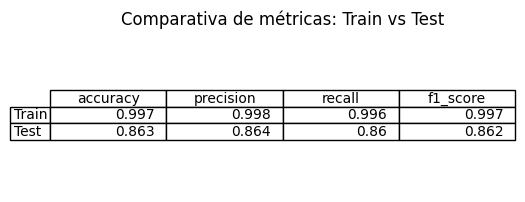

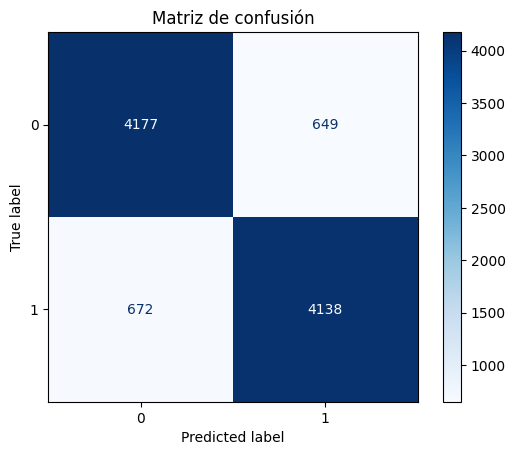

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 0.8,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': 0.5,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.1,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 8,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 100,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': 1.0,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None,
 'use_label_encoder': False}

In [10]:
testear_clasificacion(y_train, y_val, y_train_pred, y_val_pred)

data_test['sentimiento'] = best_rf.predict(X_test_a)

data_test = data_test.drop('review_es', axis=True, errors='ignore')

best_rf.get_params()

In [11]:
data_test['sentimiento'] = le.inverse_transform(best_rf.predict(X_test_a))
data_test.to_csv('submission.csv', index=False)

In [12]:
import joblib

joblib.dump(best_rf, 'xgb_model.joblib')

['xgb_model.joblib']